In [1]:
# Run this cell to set up packages for lecture.
from lec12_imports import *

# Lecture 12 – Simulation

## DSC 10, Winter 2026


### Agenda

- Recap: iteration.
- Simulations.
  - Example: What's the probability of getting 60 or more heads if we flip 100 coins?
  - Example: The "Monty Hall" Problem.


## Recap: iteration


### `for`-loops

- `for`-loops are used to repeat the execution of code for every element of a sequence.
- Lists, arrays, and strings are examples of sequences.


In [2]:
# Congrats to Olivia Dean!
for x in ["loving in your eyes", "magic in the wine", "fact that every time I fall, I lose it all"]:
    print("Maybe it's the " + x)

Maybe it's the loving in your eyes
Maybe it's the magic in the wine
Maybe it's the fact that every time I fall, I lose it all


In [3]:
# Saving the lyrics in a variable.
lyrics = ""
for x in ["loving in your eyes", "magic in the wine", "fact that every time I fall, I lose it all"]:
    lyrics = lyrics + "Maybe it's the " + x + "\n"

In [4]:
lyrics

"Maybe it's the loving in your eyes\nMaybe it's the magic in the wine\nMaybe it's the fact that every time I fall, I lose it all\n"

In [5]:
print(lyrics)

Maybe it's the loving in your eyes
Maybe it's the magic in the wine
Maybe it's the fact that every time I fall, I lose it all



### The accumulator pattern

- To store our results, we'll typically use an `int`, array, or string.


- If using an `int`, we define an `int` variable (usually set to `0`) before the loop, then use `+` to add to it inside the loop.
  - Think of this like using a tally.


- If using an array, we create an array (usually empty) before the loop, then use `np.append` to add to it inside the loop.
  - Think of this like writing the results on a piece of paper.


- If using a string, we define a string variable (usually set to `""`) before the loop, then use string concatenation `+` to add to it inside the loop.
  - Think of this like writing a word, one letter at a time.


- This pattern – of repeatedly adding to an `int`, array, or string – is called the accumulator pattern.


### `for`-loops in DSC 10

- Almost every `for`-loop in DSC 10 will use the accumulator pattern.
- Do **not** use `for`-loops to perform mathematical operations on every element of an array or Series.
  - Instead use DataFrame manipulations and built-in array or Series methods.
- Helpful video 🎥: [For Loops (and when not to use them) in DSC 10](https://www.youtube.com/watch?v=BlczSBT80fU).


### Working with strings

String are sequences, so we can iterate over them, too!


In [6]:
for letter in "uc san diego":
    print(letter.upper())

U
C
 
S
A
N
 
D
I
E
G
O


In [7]:
"california".count("a")

2

### Example: Vowel count

Below, complete the implementation of the function `vowel_count`, which returns the number of vowels in the input string `s` (including repeats). Example behavior is shown below.

```py
>>> vowel_count('king triton')
3

>>> vowel_count('i go to uc san diego')
8
```

<details>
<summary>✅ Click <b>here</b> to see the solution <b>after</b> you've tried it yourself.</summary>
    
<pre>
def vowel_count(s):
    # We need to keep track of the number of vowels seen so far. Before we start, we've seen zero vowels.
    number = 0
    
    # For each of the 5 vowels:
    for vowel in 'aeiou':
        # Count the number of occurrences of this vowel in s.
        num_vowel = s.count(vowel)
        # Add on to the running total.
        number = number + num_vowel
    # Once we've gotten through all 5 vowels, return the answer.
    return number
</pre>
</details>


In [8]:
def vowel_count(s):
    # We need to keep track of the number of vowels seen so far.
    # Before we start, we've seen zero vowels.

    # For each of the 5 vowels:

    # Count the number of occurrences of this vowel in s.

    # Add on to the running total.

    # Once we've gotten through all 5 vowels, return the answer.
    return ...

In [9]:
vowel_count("king triton")

Ellipsis

In [10]:
vowel_count("i go to uc san diego")

Ellipsis

## Simulations


### Simulations to estimate probabilities


- What is the probability of getting 60 or more heads if we flip 100 coins?


- While we _could_ calculate it by hand (and will learn how to in future courses), we can also **estimate** it using the computer:
  1. Figure out how to run the experiment (flipping 100 coins) once.
  2. Repeat the experiment many times.
  3. Find the proportion of experiments in which the number of heads was 60 or more.


- This is how we'll use **simulations** – to **estimate**, or approximate, probabilities through computation.
  - The techniques we will introduce in today's lecture will appear in almost every lecture for the remainder of the quarter!


<center><img src="images/simulation.png" width=75%</center>


### Making a random choice


- To simulate, we need a way to perform a random experiment on the computer (e.g. flipping a coin, rolling a die).


- A helpful function is `np.random.choice(options)`.
  - The input, `options`, is a list, array, or Series to choose from.
  - The output is a random element in `options`. By default, all elements are equally likely to be chosen.


In [11]:
# Simulate a fair coin flip.
np.random.choice(["Heads", "Tails"])

np.str_('Heads')

In [12]:
# Simulate a roll of a die.
np.random.choice(np.arange(1, 7))

np.int64(4)

### Making multiple random choices

`np.random.choice(options, n)` will return an array of `n` randomly selected elements from `options`.


In [13]:
# Simulate 10 fair coin flips.
np.random.choice(["Heads", "Tails"], 10)

array(['Tails', 'Heads', 'Tails', 'Heads', 'Heads', 'Heads', 'Tails',
       'Heads', 'Heads', 'Tails'], dtype='<U5')

### With replacement vs. without replacement

- By default, `np.random.choice` selects **with** replacement.
- That is, after making a selection, that option is still available.
  - e.g. if every time you draw a marble from a bag, you put it back.
- If an option can only be selected once, select **without** replacement by specifying `replace=False`.
  - e.g. if every time you draw a marble from a bag, you do not put it back.


In [14]:
# Choose three colleges to win free HDH swag.
colleges = [
    "Revelle",
    "John Muir",
    "Thurgood Marshall",
    "Earl Warren",
    "Eleanor Roosevelt",
    "Sixth",
    "Seventh",
    "Eighth",
]

np.random.choice(colleges, 3, replace=False)

array(['Seventh', 'Sixth', 'Eleanor Roosevelt'], dtype='<U17')

## Example: What's the probability of getting 60 or more heads if we flip 100 coins?


### Flipping coins

What's the probability of getting 60 or more heads if we flip 100 coins?

**Plan**:

1. Figure out how to run the experiment (flipping 100 coins) once.
2. Repeat the experiment many times.
3. Find the proportion of experiments in which the number of heads was 60 or more.


### Step 1: Figure out how to run the experiment once

- Use `np.random.choice` to flip 100 coins.
- Use `np.count_nonzero` to count the number of heads.
  - `np.count_nonzero(array)` returns the number of entries in `array` that are `True`.


In [15]:
coins = np.random.choice(["Heads", "Tails"], 100)
coins

array(['Heads', 'Tails', 'Tails', ..., 'Heads', 'Heads', 'Tails'],
      shape=(100,), dtype='<U5')

In [16]:
coins == "Heads"

array([ True, False, False, ...,  True,  True, False], shape=(100,))

In [17]:
(coins == "Heads").sum()

np.int64(45)

In [18]:
np.count_nonzero(
    coins == "Heads"
)  # Counts the number of Trues in the sequence.

np.int64(45)

In [19]:
np.count_nonzero([5, 6, 0, 2])

np.int64(3)

- **Question**: Why is it called `count_nonzero`?
- **Answer**: In Python, `True == 1` and `False == 0`, so counting the non-zero elements counts the number of `True`s.


### Aside: Defining a function to run the experiment

This makes it easy to run the experiment repeatedly.


In [20]:
def coin_experiment():
    coins = np.random.choice(["Heads", "Tails"], 100)
    return np.count_nonzero(coins == "Heads")

In [21]:
coin_experiment()

np.int64(46)

### Step 2: Repeat the experiment many times

- How do we run a piece of code many times? **Using a `for`-loop!**
- Each time we run the experiment, we'll need to store the results in an array.
  - To do this, we'll use `np.append`!


In [22]:
head_counts = np.array([])
head_counts

array([], dtype=float64)

In [23]:
head_counts = np.append(head_counts, 15)
head_counts

array([15.])

In [24]:
head_counts = np.append(head_counts, 25)
head_counts

array([15., 25.])

### Step 2: Repeat the experiment many times

- Imagine we start with a blank sheet of paper, and each time we run the experiment, we write the number of heads we see down on the sheet of paper.
- The sheet will start off empty, but eventually will have one number for each time we ran the experiment.


In [25]:
# Specify the number of repetitions.
repetitions = 10000

# Create an empty array to store the results.
head_counts = np.array([])

for i in np.arange(repetitions):
    # For each repetition, run the experiment and add the result to head_counts.
    head_count = coin_experiment()
    head_counts = np.append(head_counts, head_count)

In [26]:
len(head_counts)

10000

In [27]:
head_counts

array([52., 46., 48., ..., 48., 41., 53.], shape=(10000,))

### Step 3: Find the proportion of experiments in which the number of heads was 60 or more


In [28]:
# In how many experiments was the number of heads >= 60?
at_least_60 = np.count_nonzero(head_counts >= 60)
at_least_60

np.int64(291)

In [29]:
# What is this as a proportion?
at_least_60 / repetitions

np.float64(0.0291)

In [30]:
# Can also use np.mean()! Why?
np.mean(head_counts >= 60)

np.float64(0.0291)

This is quite close to the true theoretical answer!


In [31]:
# The theoretical answer – don't worry about how or why this code works.
import math

sum([math.comb(100, i) * (1 / 2) ** 100 for i in np.arange(60, 101)])

0.028443966820490395

### Visualizing the distribution


In [32]:
head_counts

array([52., 46., 48., ..., 48., 41., 53.], shape=(10000,))

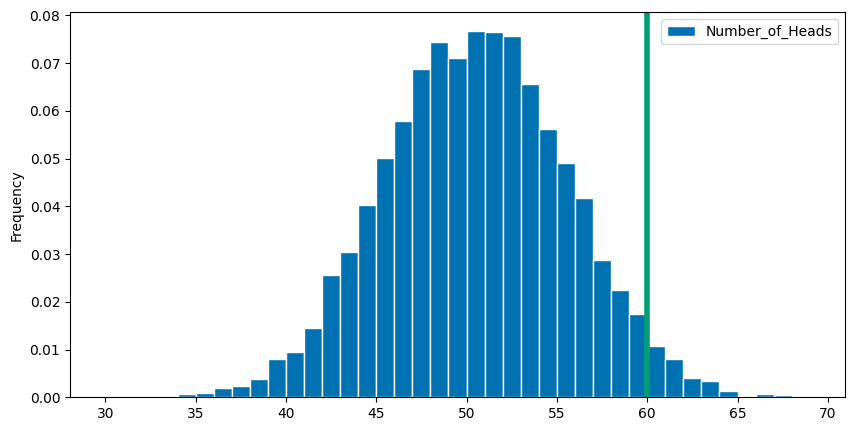

In [33]:
bpd.DataFrame().assign(Number_of_Heads=head_counts).plot(
    kind="hist", bins=np.arange(30, 70), density=True, ec="w", figsize=(10, 5)
)
plt.axvline(60, color="C1", linewidth=4);

- This histogram describes the distribution of the number of heads in each experiment.
- Now we see another reason to use density histograms.
  - Using density means that areas are **probabilities**.
- Next class, we'll learn more about _why_ it's valid to estimate probabilities using simulations.


## Example: The "Monty Hall" Problem


### The "Monty Hall" Problem

Suppose you’re on a game show, and you’re given the choice of three doors. A car 🚗 is behind one of the doors, and goats 🐐🐐 are behind the other two.

- You pick a door, say Door #2, and the host, **who knows what’s behind the doors**, opens another door, say Door #3, which has a goat.

- The host then says to you, “Do you want to switch to Door #1 or stay with Door #2?”

- **Question**: Should you stay or switch?

_(The question was posed in Parade magazine’s "Ask Marilyn" column in 1990. It is called the "Monty Hall problem" because Monty Hall hosted a similar game show called "Let's Make a Deal.")_


### Let's play!

Below, we've embedded the Monty Hall simulator from [this site](https://montyhall.io/).


In [34]:
from IPython.display import IFrame

IFrame("https://montyhall.io/", width=600, height=400)

### Concept Check ✅ – Answer at [cc.dsc10.com](http://cc.dsc10.com)

Suppose you originally selected Door #2. The host reveals Door #3 to have a goat behind it. What should you do?

A. **Stay** with Door #2; it has just as high a chance of winning as Door #1. It doesn't matter whether you switch or not.

B. **Switch** to Door #1; it has a higher chance of winning than Door #2.


### Time to simulate!


- Let's **estimate** the probability of winning if you switch.


- If it's higher than 50%, then switching is the better strategy, otherwise staying is the better strategy.


**Plan**:

1. Figure out how to simulate a single game.
2. Play the game many times, switching each time.
3. Compute the proportion of wins.


### Step 1: Simulate a single game

When you pick a door, there are three equally-likely outcomes for what is behind the door you picked:

- Car.
- Goat #1.
- Goat #2.


In [35]:
options = np.array(["Car", "Goat #1", "Goat #2"])
behind_picked_door = np.random.choice(options)
behind_picked_door

np.str_('Goat #1')

### Step 1: Simulate a single game

When the host opens a different door, they always reveal a goat.


In [36]:
if behind_picked_door == "Goat #1":
    revealed = "Goat #2"
elif behind_picked_door == "Goat #2":
    revealed = "Goat #1"
else:
    # This is the case in which you originally picked a car!
    revealed = np.random.choice(["Goat #1", "Goat #2"])

revealed

'Goat #2'

If you always switch, you'll end up winning the prize that is neither `behind_picked_door` nor `revealed`.


In [37]:
options

array(['Car', 'Goat #1', 'Goat #2'], dtype='<U7')

In [38]:
behind_picked_door

np.str_('Goat #1')

In [39]:
revealed

'Goat #2'

In [40]:
# Don't worry about the code for this part.
your_prize = options[(options != behind_picked_door) & (options != revealed)][
    0
]
your_prize

np.str_('Car')

### Step 1: Simulate a single game

Let's put all of our work into a single function to make it easier to repeat.


In [41]:
def simulate_switch_strategy():
    options = np.array(["Car", "Goat #1", "Goat #2"])
    behind_picked_door = np.random.choice(options)

    if behind_picked_door == "Goat #1":
        revealed = "Goat #2"
    elif behind_picked_door == "Goat #2":
        revealed = "Goat #1"
    else:
        revealed = np.random.choice(["Goat #1", "Goat #2"])

    your_prize = options[
        (options != behind_picked_door) & (options != revealed)
    ][0]

    # print(behind_picked_door, 'was behind the door.', revealed, 'was revealed by the host. Your prize was:', your_prize)
    return your_prize

Now, every time we call `simulate_switch_strategy`, the result is your prize.


In [42]:
simulate_switch_strategy()

np.str_('Car')

### Step 2: Play the game many times

We should save your prize in each game; to do so, we'll use `np.append`.


In [43]:
repetitions = 10000

your_prizes = np.array([])

for i in np.arange(repetitions):
    your_prize = simulate_switch_strategy()
    your_prizes = np.append(your_prizes, your_prize)

In [44]:
your_prizes

array(['Car', 'Goat #2', 'Car', ..., 'Goat #1', 'Car', 'Car'],
      shape=(10000,), dtype='<U32')

### Step 3: Count the proportion of wins for this strategy (switching)


In [45]:
your_prizes

array(['Car', 'Goat #2', 'Car', ..., 'Goat #1', 'Car', 'Car'],
      shape=(10000,), dtype='<U32')

In [46]:
np.count_nonzero(your_prizes == "Car")

np.int64(6708)

In [47]:
np.count_nonzero(your_prizes == "Car") / repetitions

np.float64(0.6708)

This is quite close to the true probability of winning if you switch, $\frac{2}{3}$.


### Alternate implementation


- Looking back at our implementation, we kept track of your prize in each game.


- However, all we really needed to keep track of was the **number of games** in which you won a car.


- **💡 Idea**: Keep a _tally_ of the number of times you won a car. That is, initialize `car_count` to 0, and add 1 to it each time your prize is a car.


In [48]:
car_count = 0

In [49]:
for i in np.arange(repetitions):
    your_prize = simulate_switch_strategy()
    if your_prize == "Car":
        car_count = car_count + 1

In [50]:
car_count / repetitions

0.6678

No arrays needed! This strategy won't always work; it depends on the goal of the simulation.


### What if you always stay with your original door?

In this case, your prize is always the same as what was behind the picked door.


In [51]:
car_count = 0

for i in np.arange(repetitions):
    options = np.array(["Car", "Goat #1", "Goat #2"])
    behind_picked_door = np.random.choice(options)
    your_prize = behind_picked_door
    if your_prize == "Car":
        car_count = car_count + 1

car_count / repetitions

0.3389

- This is quite close to the true probability of winning if you stay, $\frac{1}{3}$.


- **Conclusion**: It's better to switch.


- **Why?**
  - If you originally choose a goat, Monty will reveal the other goat, and you'll win the car by switching.
  - If you originally choose a car, you'll win by staying.
  - But there are 2 goats and only 1 car, so you win twice as often by switching.


### Marilyn vos Savant's column in Parade magazine

<div style="display: flex; margin-top: .5in; margin-right: 1in">
<div style="width: 65%;">
    <ul>
        <li>When asked this question by a reader, vos Savant stated the correct answer: <i>switch</i>.</li>
        <li>She received over 10,000 letters in disagreement, including over 1,000 letters from people with Ph.D.s.</li>
        <li>This became a nationwide controversy, even getting a <a href='https://www.nytimes.com/1991/07/21/us/behind-monty-hall-s-doors-puzzle-debate-and-answer.html'>front-page New York Times article in 1991.</a></li>
    </ul>
</div>
<center><img src="images/vos_savant.jpg" width=300></center>
</div>

## Summary


### Simulations find probabilities

- Calculating probabilities is important, but can be hard!
  - You'll learn plenty of formulas in future DSC classes, if you end up taking them.
- Simulations let us find probabilities through code rather than through math.
- Many real-world scenarios are complicated.
  - Simulations are much easier than math in many of these cases.


### The simulation "recipe" 👩‍🍳

To estimate the probability of an event through simulation:

1. Make a function that runs the experiment once.
2. Run that function many times (usually 10,000) with a `for`-loop, and save the results in an array with `np.append`.
3. Compute the proportion of times the event occurs using `np.count_nonzero`.
